In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("heart.csv")

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
encode = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

In [ ]:
df = pd.get_dummies(data=df, prefix=encode, columns=encode)

In [ ]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [ ]:
features = [x for x in df.columns if x not in "HeartDisease"]
RANDOM_STATE = 1

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df[features], df["HeartDisease"], train_size=0.8, random_state=RANDOM_STATE)

In [ ]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None]

In [ ]:
min_train_list = []
min_test_list = []

for min_sample_split in min_samples_split_list:
  model = RandomForestClassifier(min_samples_split = min_sample_split, random_state = RANDOM_STATE).fit(x_train, y_train)
  train_predict = model.predict(x_train)
  test_predict = model.predict(x_test)
  train_acc = accuracy_score(train_predict, y_train)
  test_acc = accuracy_score(test_predict, y_test)

  min_train_list.append(train_acc)
  min_test_list.append(test_acc)

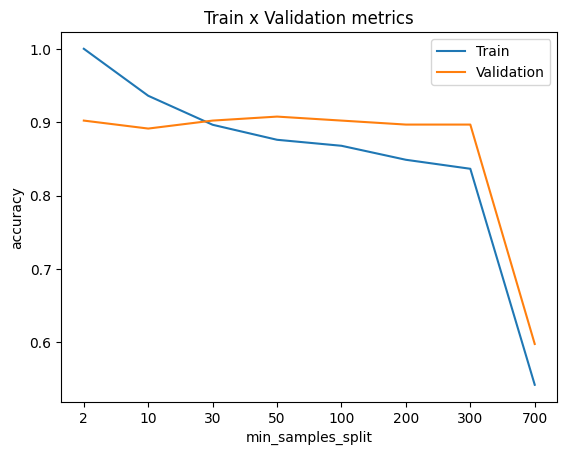

In [ ]:
plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(min_train_list)
plt.plot(min_test_list)
plt.legend(['Train','Validation'])

In [ ]:
depth_train_list = []
depth_test_list = []

for max_depth in max_depth_list:
  model = RandomForestClassifier(max_depth=max_depth, random_state=RANDOM_STATE).fit(x_train, y_train)
  train_pred = model.predict(x_train)
  test_pred = model.predict(x_test)
  train_acc = accuracy_score(train_pred, y_train)
  test_acc = accuracy_score(test_pred, y_test)

  depth_train_list.append(train_acc)
  depth_test_list.append(test_acc)

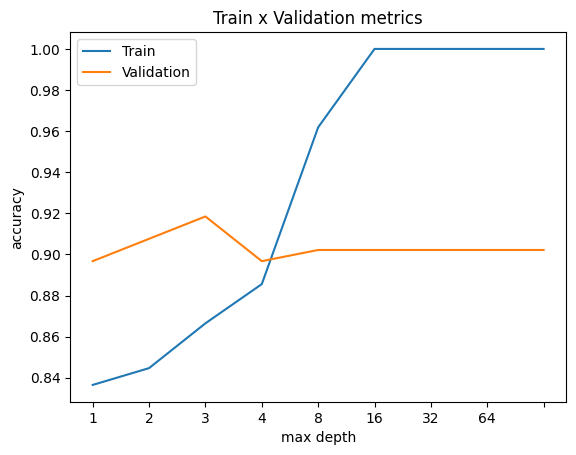

In [ ]:
plt.title('Train x Validation metrics')
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(depth_train_list)
plt.plot(depth_test_list)
plt.legend(['Train','Validation'])

In [ ]:
n_estimators_list = [10,50,100,500]

In [ ]:
n_test_list = []
n_train_list = []

for estimator in n_estimators_list:
  model = RandomForestClassifier(n_estimators = estimator, random_state = RANDOM_STATE).fit(x_train, y_train)
  train_predict = model.predict(x_train)
  test_predict = model.predict(x_test)
  train_acc = accuracy_score(train_predict, y_train)
  test_acc = accuracy_score(test_predict, y_test)

  n_test_list.append(test_acc)
  n_train_list.append(train_acc)

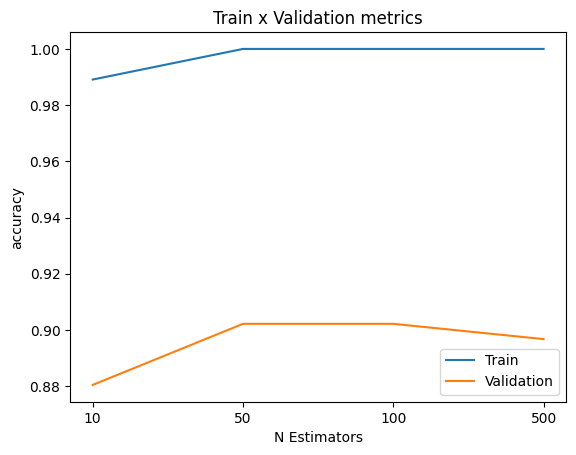

In [ ]:
plt.title('Train x Validation metrics')
plt.xlabel('N Estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(n_train_list)
plt.plot(n_test_list)
plt.legend(['Train','Validation'])

In [ ]:
model = RandomForestClassifier(min_samples_split = 10, max_depth = 8, n_estimators = 100, random_state = RANDOM_STATE).fit(x_train, y_train)
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)
train_acc = accuracy_score(train_pred, y_train)
test_acc = accuracy_score(test_pred, y_test)

print(f"training accuracy: {train_acc}")
print(f"test accuracy: {test_acc}")

training accuracy: 0.9209809264305178
test accuracy: 0.8967391304347826
